# Numerical Stability and Regularization for an IMDB MLP

This notebook keeps the earlier IMDB MLP experiment comparable while adding explicit safeguards against unstable gradients and overfitting.

## Vanishing and exploding gradients

Backpropagation repeatedly multiplies local derivatives and weight matrices. When their effective scales stay below one, gradients shrink toward zero and early layers learn very slowly. When the scales stay above one, gradients grow rapidly, causing oversized updates, overflow, or non-finite values. Saturating activations strengthen vanishing because their derivatives approach zero; excessive weight scales, depth, long recurrent paths, and aggressive learning rates strengthen exploding.

Finite precision does not create the underlying multiplication problem, but it determines when a tiny gradient rounds away or a large value overflows. Stable training therefore controls signal scale and uses numerically stable operations instead of relying on higher precision alone.

## Main techniques

Useful stability techniques include activation-aware initialization, input or hidden-state normalization, non-saturating activations, residual or gated paths, conservative learning rates, gradient clipping, and stable fused losses. Mixed-precision training also needs appropriate loss scaling.

Regularization limits generalization error rather than merely keeping arithmetic finite. Common choices are L1 or L2 penalties and decoupled weight decay, dropout, data augmentation, label smoothing, early stopping, reduced model capacity, and ensembles. Batch normalization may have a mild regularizing side effect, but its main role here is scale control.

## Experiment design

The data split, 20,000-feature TF-IDF representation, hidden widths, ReLU activations, learning rate, batch size, and eight-epoch budget match the original MLP. The new fixed configuration adds 40% dropout after each hidden activation, AdamW weight decay of `1e-4` on weight matrices, and a gradient-norm ceiling of `1.0`. Kaiming initialization, hidden batch normalization, L2-normalized inputs, and `BCEWithLogitsLoss` provide the numerical-stability safeguards. Validation results diagnose generalization, but no checkpoint or hyperparameter is selected in this experiment; the next roadmap task covers model selection.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
part_06 = phase_1 / "06-vectorization"
sys.path.insert(0, str(part_02 / "src"))
sys.path.insert(0, str(part_06 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize
from vectorizer import CustomTfidfVectorizer

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path)
required_columns = {"review", "sentiment"}
if not required_columns.issubset(imdb.columns):
    raise KeyError(f"The IMDB dataset must contain {sorted(required_columns)}.")
imdb = imdb.dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")

def model_visible_text(review):
    cleaned = preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
    return " ".join(
        token
        for token in regex_tokenize(cleaned)
        if token.isalpha() and len(token) >= 2
    )


imdb["model_visible_text"] = imdb["review"].map(model_visible_text)
if imdb["model_visible_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")
if imdb.groupby("model_visible_text")["label"].nunique().gt(1).any():
    raise ValueError("Reviews identical after preprocessing have conflicting labels.")
original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_visible_text").reset_index(drop=True)

development, test = train_test_split(
    imdb,
    test_size=0.20,
    random_state=SEED,
    stratify=imdb["label"],
)
train, validation = train_test_split(
    development,
    test_size=0.25,
    random_state=SEED,
    stratify=development["label"],
)

split_frames = {"train": train, "validation": validation, "test": test}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert set(split_frames[left]["model_visible_text"]).isdisjoint(
        split_frames[right]["model_visible_text"]
    )

X_train, y_train = train["review"], train["label"]
X_validation, y_validation = validation["review"], validation["label"]
X_test, y_test = test["review"], test["label"]

split_summary = pd.DataFrame(
    {
        "reviews": [len(X_train), len(X_validation), len(X_test)],
        "positive proportion": [y_train.mean(), y_validation.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)

print(f"PyTorch: {torch.__version__}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}"}))

PyTorch: 2.13.0+cpu
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Reviews retained: 49,580 (420 duplicates removed)
Model-visible review overlap across splits: 0


,reviews,positive proportion
train,29748,0.5019
validation,9916,0.5019
test,9916,0.5019


In [2]:
vectorizer = CustomTfidfVectorizer(
    preprocessor=preprocess_text,
    tokenizer=regex_tokenize,
    min_df=5,
    max_df=0.95,
    max_features=20_000,
)
input_normalizer = Normalizer(norm="l2", copy=False)

vectorization_start = time.perf_counter()
X_train_tfidf = input_normalizer.fit_transform(
    vectorizer.fit_transform(X_train)
).astype(np.float32)
X_validation_tfidf = input_normalizer.transform(
    vectorizer.transform(X_validation)
).astype(np.float32)
X_test_tfidf = input_normalizer.transform(
    vectorizer.transform(X_test)
).astype(np.float32)
vectorization_seconds = time.perf_counter() - vectorization_start

train_norms = np.sqrt(X_train_tfidf.multiply(X_train_tfidf).sum(axis=1)).A1
nonzero_norms = train_norms[train_norms > 0]
density = X_train_tfidf.nnz / np.prod(X_train_tfidf.shape)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Training matrix density: {density:.4%}")
print(f"Mean non-empty training-row L2 norm: {nonzero_norms.mean():.6f}")
print(f"Vectorization time: {vectorization_seconds:.2f} seconds")
assert np.allclose(nonzero_norms, 1.0, atol=1e-5)

Vocabulary size: 20,000
Training matrix shape: (29748, 20000)
Training matrix density: 0.6252%
Mean non-empty training-row L2 norm: 1.000000
Vectorization time: 17.85 seconds


## Stable, regularized MLP

The sparse input stays sparse through the first projection. Kaiming initialization preserves variance for ReLU, batch normalization controls each hidden layer's scale, and the fused binary-cross-entropy loss avoids separately computing a sigmoid and logarithm. Dropout randomly masks hidden activations during training. AdamW applies decoupled weight decay only to weight matrices, leaving biases and normalization parameters unpenalized.

In [3]:
class RegularizedSentimentMLP(nn.Module):
    def __init__(self, input_features, dropout_probability):
        super().__init__()
        self.hidden_1 = nn.Linear(input_features, 128)
        self.normalization_1 = nn.BatchNorm1d(128)
        self.dropout_1 = nn.Dropout(dropout_probability)
        self.hidden_2 = nn.Linear(128, 64)
        self.normalization_2 = nn.BatchNorm1d(64)
        self.dropout_2 = nn.Dropout(dropout_probability)
        self.output = nn.Linear(64, 1)
        nn.init.kaiming_normal_(self.hidden_1.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden_1.bias)
        nn.init.kaiming_normal_(self.hidden_2.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden_2.bias)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, features):
        if features.is_sparse:
            hidden = torch.sparse.mm(features, self.hidden_1.weight.T)
            hidden = hidden + self.hidden_1.bias
        else:
            hidden = self.hidden_1(features)
        hidden = self.dropout_1(torch.relu(self.normalization_1(hidden)))
        hidden = self.dropout_2(
            torch.relu(self.normalization_2(self.hidden_2(hidden)))
        )
        return self.output(hidden).squeeze(1)


dropout_probability = 0.40
weight_decay = 1e-4
gradient_norm_ceiling = 1.0
model = RegularizedSentimentMLP(
    X_train_tfidf.shape[1], dropout_probability
).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
expected_hidden_1_std = np.sqrt(2 / model.hidden_1.in_features)
observed_hidden_1_std = model.hidden_1.weight.detach().std().item()

print(model)
print(f"Trainable parameters: {parameter_count:,}")
print(f"Dropout probability: {dropout_probability:.2f}")
print(f"Weight decay: {weight_decay:.1e}")
print(f"Gradient-norm ceiling: {gradient_norm_ceiling:.1f}")
print(f"First-layer expected Kaiming std: {expected_hidden_1_std:.6f}")
print(f"First-layer observed weight std: {observed_hidden_1_std:.6f}")
assert abs(observed_hidden_1_std / expected_hidden_1_std - 1.0) < 0.05

RegularizedSentimentMLP(
  (hidden_1): Linear(in_features=20000, out_features=128, bias=True)
  (normalization_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout_1): Dropout(p=0.4, inplace=False)
  (hidden_2): Linear(in_features=128, out_features=64, bias=True)
  (normalization_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout_2): Dropout(p=0.4, inplace=False)
  (output): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 2,568,833
Dropout probability: 0.40
Weight decay: 1.0e-04
Gradient-norm ceiling: 1.0
First-layer expected Kaiming std: 0.010000
First-layer observed weight std: 0.009999


## Fixed-budget training

Gradient norms are measured before clipping. A non-finite loss or gradient immediately stops the experiment, so a completed run also verifies that every optimization step stayed numerically finite.

Epoch  1/8 | train loss 0.3978 | validation loss 0.3413 | validation accuracy 0.8942 | validation F1 0.8976 | max gradient norm 3.6659


Epoch  2/8 | train loss 0.1470 | validation loss 0.2720 | validation accuracy 0.8916 | validation F1 0.8930 | max gradient norm 2.8317


Epoch  3/8 | train loss 0.0640 | validation loss 0.3218 | validation accuracy 0.8843 | validation F1 0.8866 | max gradient norm 2.1215


Epoch  4/8 | train loss 0.0280 | validation loss 0.3756 | validation accuracy 0.8811 | validation F1 0.8816 | max gradient norm 1.0523


Epoch  5/8 | train loss 0.0151 | validation loss 0.4185 | validation accuracy 0.8776 | validation F1 0.8793 | max gradient norm 2.0204


Epoch  6/8 | train loss 0.0096 | validation loss 0.4683 | validation accuracy 0.8749 | validation F1 0.8736 | max gradient norm 1.1617


Epoch  7/8 | train loss 0.0068 | validation loss 0.4922 | validation accuracy 0.8745 | validation F1 0.8767 | max gradient norm 0.3800


Epoch  8/8 | train loss 0.0046 | validation loss 0.5205 | validation accuracy 0.8743 | validation F1 0.8729 | max gradient norm 0.3402


,train loss,validation loss,validation accuracy,validation F1,maximum gradient norm
epoch,,,,,
1,0.3978,0.3413,0.8942,0.8976,3.6659
2,0.1470,0.2720,0.8916,0.8930,2.8317
3,0.0640,0.3218,0.8843,0.8866,2.1215
4,0.0280,0.3756,0.8811,0.8816,1.0523
5,0.0151,0.4185,0.8776,0.8793,2.0204
6,0.0096,0.4683,0.8749,0.8736,1.1617
7,0.0068,0.4922,0.8745,0.8767,0.3800
8,0.0046,0.5205,0.8743,0.8729,0.3402


Training and validation time: 37.22 seconds
Maximum pre-clipping gradient norm: 3.6659
Updates clipped: 63 of 472


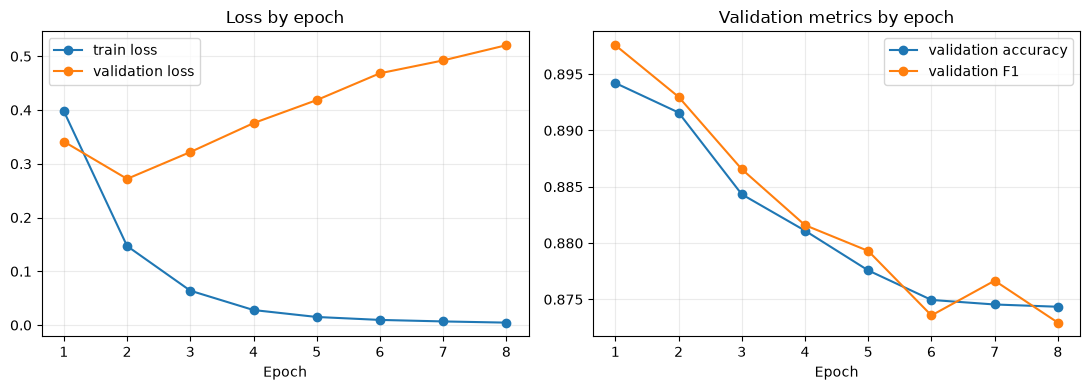

In [4]:
def to_sparse_batch(matrix, indices):
    batch = matrix[indices].tocoo()
    coordinates = np.vstack((batch.row, batch.col)).astype(np.int64)
    return torch.sparse_coo_tensor(
        torch.from_numpy(coordinates),
        torch.from_numpy(batch.data),
        size=batch.shape,
        device=device,
        check_invariants=False,
    ).coalesce()


def evaluate_model(model, matrix, labels, batch_size):
    model.eval()
    total_loss = 0.0
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(labels), batch_size):
            indices = np.arange(start, min(start + batch_size, len(labels)))
            features = to_sparse_batch(matrix, indices)
            targets = torch.from_numpy(labels[indices]).to(device)
            logits = model(features)
            loss = loss_function(logits, targets)
            total_loss += loss.item() * len(indices)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return total_loss / len(labels), np.concatenate(probabilities)


decay_parameters = []
no_decay_parameters = []
for parameter in model.parameters():
    if parameter.ndim > 1:
        decay_parameters.append(parameter)
    else:
        no_decay_parameters.append(parameter)

batch_size = 512
epochs = 8
learning_rate = 1e-3
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    [
        {"params": decay_parameters, "weight_decay": weight_decay},
        {"params": no_decay_parameters, "weight_decay": 0.0},
    ],
    lr=learning_rate,
)
y_train_array = y_train.to_numpy(dtype=np.float32)
y_validation_array = y_validation.to_numpy(dtype=np.float32)
history = []
all_gradient_norms = []
training_start = time.perf_counter()

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    epoch_gradient_norms = []
    shuffled_indices = np.random.default_rng(SEED + epoch).permutation(
        len(y_train_array)
    )
    for start in range(0, len(y_train_array), batch_size):
        indices = shuffled_indices[start:start + batch_size]
        features = to_sparse_batch(X_train_tfidf, indices)
        targets = torch.from_numpy(y_train_array[indices]).to(device)
        optimizer.zero_grad()
        logits = model(features)
        loss = loss_function(logits, targets)
        if not torch.isfinite(loss):
            raise FloatingPointError("Training produced a non-finite loss.")
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(), gradient_norm_ceiling, error_if_nonfinite=True
        ).item()
        optimizer.step()
        epoch_loss += loss.item() * len(indices)
        epoch_gradient_norms.append(gradient_norm)

    all_gradient_norms.extend(epoch_gradient_norms)
    train_loss = epoch_loss / len(y_train_array)
    validation_loss, validation_probabilities = evaluate_model(
        model, X_validation_tfidf, y_validation_array, batch_size
    )
    validation_predictions = (validation_probabilities >= 0.5).astype(int)
    history.append(
        {
            "epoch": epoch,
            "train loss": train_loss,
            "validation loss": validation_loss,
            "validation accuracy": accuracy_score(
                y_validation_array, validation_predictions
            ),
            "validation F1": f1_score(
                y_validation_array, validation_predictions
            ),
            "maximum gradient norm": max(epoch_gradient_norms),
        }
    )
    row = history[-1]
    print(
        f"Epoch {epoch:>2}/{epochs} | train loss {row['train loss']:.4f} | "
        f"validation loss {row['validation loss']:.4f} | "
        f"validation accuracy {row['validation accuracy']:.4f} | "
        f"validation F1 {row['validation F1']:.4f} | "
        f"max gradient norm {row['maximum gradient norm']:.4f}"
    )

training_seconds = time.perf_counter() - training_start
history_frame = pd.DataFrame(history).set_index("epoch")
display(history_frame.style.format("{:.4f}"))
print(f"Training and validation time: {training_seconds:.2f} seconds")
print(f"Maximum pre-clipping gradient norm: {max(all_gradient_norms):.4f}")
print(
    f"Updates clipped: {sum(value > gradient_norm_ceiling for value in all_gradient_norms)} "
    f"of {len(all_gradient_norms)}"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_frame[["train loss", "validation loss"]].plot(
    ax=axes[0], marker="o"
)
history_frame[["validation accuracy", "validation F1"]].plot(
    ax=axes[1], marker="o"
)
axes[0].set_title("Loss by epoch")
axes[1].set_title("Validation metrics by epoch")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## Held-out comparison

The regularized final epoch is evaluated once on the untouched test set. The original row comes from the previously executed unregularized notebook, which used the same split, representation, architecture widths, and fixed training budget.

,loss,accuracy,precision,recall,F1,ROC AUC,accuracy change
original MLP,0.3829,0.8791,0.8854,0.8720,0.8786,0.9508,0.0000
regularized MLP,0.5172,0.8757,0.8879,0.8610,0.8742,0.9473,-0.0034


              precision    recall  f1-score   support

    negative     0.8640    0.8905    0.8771      4939
    positive     0.8879    0.8610    0.8742      4977

    accuracy                         0.8757      9916
   macro avg     0.8760    0.8757    0.8756      9916
weighted avg     0.8760    0.8757    0.8756      9916



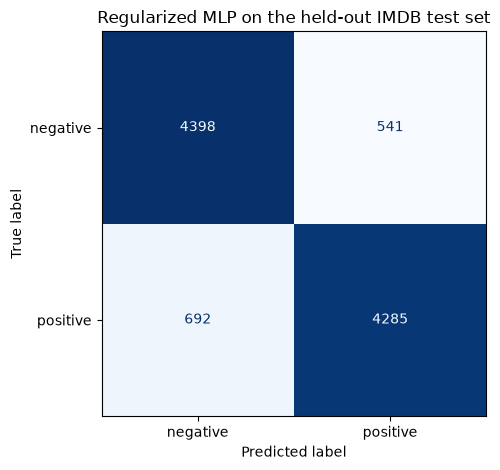

In [5]:
y_test_array = y_test.to_numpy(dtype=np.float32)
test_loss, test_probabilities = evaluate_model(
    model, X_test_tfidf, y_test_array, batch_size
)
test_predictions = (test_probabilities >= 0.5).astype(int)
regularized_metrics = {
    "loss": test_loss,
    "accuracy": accuracy_score(y_test_array, test_predictions),
    "precision": precision_score(y_test_array, test_predictions),
    "recall": recall_score(y_test_array, test_predictions),
    "F1": f1_score(y_test_array, test_predictions),
    "ROC AUC": roc_auc_score(y_test_array, test_probabilities),
}
comparison = pd.DataFrame(
    {
        "original MLP": {
            "loss": 0.3829,
            "accuracy": 0.8791,
            "precision": 0.8854,
            "recall": 0.8720,
            "F1": 0.8786,
            "ROC AUC": 0.9508,
        },
        "regularized MLP": regularized_metrics,
    }
).T
comparison["accuracy change"] = comparison["accuracy"] - comparison.loc["original MLP", "accuracy"]
display(comparison.style.format("{:.4f}"))
print(classification_report(
    y_test_array,
    test_predictions,
    target_names=["negative", "positive"],
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    y_test_array,
    test_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Regularized MLP on the held-out IMDB test set")
plt.tight_layout()
plt.show()

assert np.isfinite(comparison.to_numpy()).all()
assert len(test_predictions) == len(y_test_array)

## Observations

The regularized final epoch reached test accuracy `0.8757`, F1 `0.8742`, and ROC AUC `0.9473`. The original fixed-eight-epoch MLP reached `0.8791`, `0.8786`, and `0.9508`, respectively, so regularization lowered test accuracy by `0.0034` in this fixed configuration. This is evidence that useful techniques do not guarantee an improvement when their strengths and training duration are not selected on validation data.

Dropout and weight decay did slow memorization: final training loss was `0.0046` instead of the original `0.0009`. They did not remove overfitting, because regularized validation loss was best at `0.2720` after epoch 2 and rose to `0.5205` by epoch 8. Validation accuracy peaked at `0.8942` after epoch 1, slightly above the original peak of `0.8939`; selecting that earlier state belongs to the following model-selection task.

All losses and gradients remained finite. The maximum pre-clipping gradient norm was `3.6659`, and clipping constrained 63 of 472 updates to the `1.0` ceiling. This shows that the safeguard was active even though the compact network did not suffer a numerical failure. The installed PyTorch build was CPU-only, so the detected NVIDIA GeForce RTX 3050 Ti could not be used; vectorization took `17.85` seconds and training with validation took `37.22` seconds on CPU.